In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

import scipy.stats as stats
import statsmodels.api as sm
from tqdm import tqdm

In [2]:
path = './data/US_youtube_trending_data.csv'
df = pd.read_csv(path)

# Overview

In [3]:
df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,3C66w5Z0ixs,I ASKED HER TO BE MY GIRLFRIEND...,2020-08-11T19:20:14Z,UCvtRTOMP2TqYqu51xNrqAzg,Brawadis,22,2020-08-12T00:00:00Z,brawadis|prank|basketball|skits|ghost|funny vi...,1514614,156908,5855,35313,https://i.ytimg.com/vi/3C66w5Z0ixs/default.jpg,False,False,SUBSCRIBE to BRAWADIS ▶ http://bit.ly/Subscrib...
1,M9Pmf9AB4Mo,Apex Legends | Stories from the Outlands – “Th...,2020-08-11T17:00:10Z,UC0ZV6M2THA81QT9hrVWJG3A,Apex Legends,20,2020-08-12T00:00:00Z,Apex Legends|Apex Legends characters|new Apex ...,2381688,146739,2794,16549,https://i.ytimg.com/vi/M9Pmf9AB4Mo/default.jpg,False,False,"While running her own modding shop, Ramya Pare..."
2,J78aPJ3VyNs,I left youtube for a month and THIS is what ha...,2020-08-11T16:34:06Z,UCYzPXprvl5Y-Sf0g4vX-m6g,jacksepticeye,24,2020-08-12T00:00:00Z,jacksepticeye|funny|funny meme|memes|jacksepti...,2038853,353787,2628,40221,https://i.ytimg.com/vi/J78aPJ3VyNs/default.jpg,False,False,I left youtube for a month and this is what ha...
3,kXLn3HkpjaA,XXL 2020 Freshman Class Revealed - Official An...,2020-08-11T16:38:55Z,UCbg_UMjlHJg_19SZckaKajg,XXL,10,2020-08-12T00:00:00Z,xxl freshman|xxl freshmen|2020 xxl freshman|20...,496771,23251,1856,7647,https://i.ytimg.com/vi/kXLn3HkpjaA/default.jpg,False,False,Subscribe to XXL → http://bit.ly/subscribe-xxl...
4,VIUo6yapDbc,Ultimate DIY Home Movie Theater for The LaBran...,2020-08-11T15:10:05Z,UCDVPcEbVLQgLZX0Rt6jo34A,Mr. Kate,26,2020-08-12T00:00:00Z,The LaBrant Family|DIY|Interior Design|Makeove...,1123889,45802,964,2196,https://i.ytimg.com/vi/VIUo6yapDbc/default.jpg,False,False,Transforming The LaBrant Family's empty white ...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268787 entries, 0 to 268786
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   video_id           268787 non-null  object
 1   title              268787 non-null  object
 2   publishedAt        268787 non-null  object
 3   channelId          268787 non-null  object
 4   channelTitle       268787 non-null  object
 5   categoryId         268787 non-null  int64 
 6   trending_date      268787 non-null  object
 7   tags               268787 non-null  object
 8   view_count         268787 non-null  int64 
 9   likes              268787 non-null  int64 
 10  dislikes           268787 non-null  int64 
 11  comment_count      268787 non-null  int64 
 12  thumbnail_link     268787 non-null  object
 13  comments_disabled  268787 non-null  bool  
 14  ratings_disabled   268787 non-null  bool  
 15  description        264238 non-null  object
dtypes: bool(2), int64(5)

## Codebook

- **video_id**: id of video 
- **title**: title of the video
- **publishedAt**: date of published video  
- **channelId**: Id of the channel 
- **channelTitle**: title of the channel 
- **categoryId**: Id of the category  (categorical data)
- **trending_date**: trending date of the video 
- **tags**: tags of the video  
- **view_count**: view count of the video
- **likes**: number of likes  
- **dislikes**: number of dislikes  
- **comment_count**: number of comments  
- **thumbnail_link**: url of the thumbnail image 
- **comments_disabled**: boolen : comments disabled or not
- **ratings_disabled**: rating disabled or not
- **description**: description of the video 

# EDA before preprocessing

### Descriptive Analytics

In [9]:
def number_of_unique_values(df):
    unique_counts = df.nunique()
    print("Number of unique values in each column:")
    print(unique_counts)

In [10]:
number_of_unique_values(df)

Number of unique values in each column:
video_id              47142
title                 48471
publishedAt           46554
channelId              8302
channelTitle           8543
categoryId               15
trending_date          1323
tags                  32909
view_count           255236
likes                136839
dislikes              13179
comment_count         35557
thumbnail_link        47142
comments_disabled         2
ratings_disabled          2
description           48448
dtype: int64


##### ==> Categorical must be : ```categoryId```, `channelId`, `channelTitle`, `comments_disabled`, `ratings_disabled`

### Distribution of categorical data

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_distribution(df, column):
    plt.figure(figsize=(10, 6))
    
    ax = sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)

    # Add numbers on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center', va='bottom',
            xytext=(0, 3),
            textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()

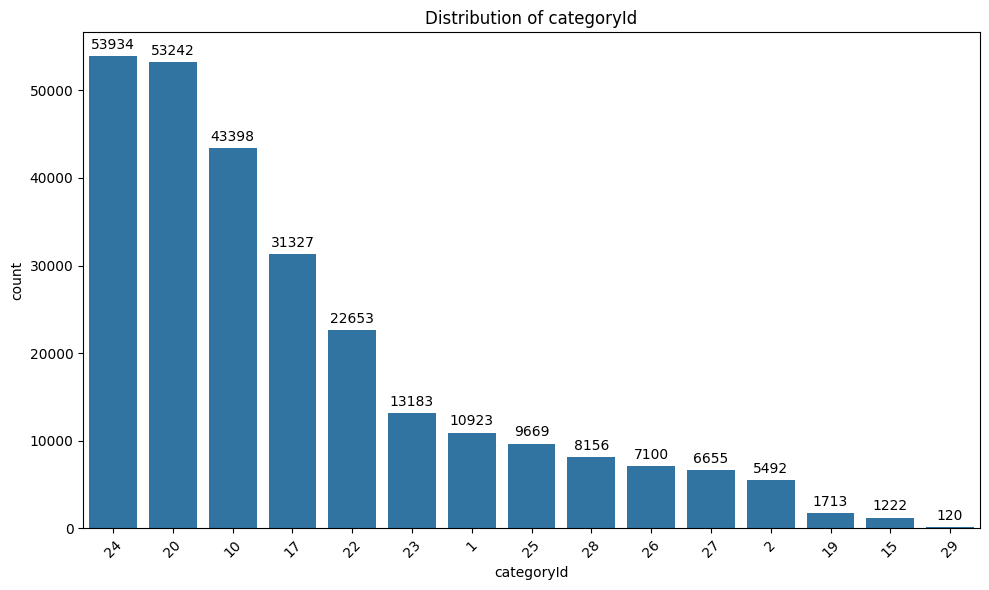

In [23]:
plot_categorical_distribution(df, 'categoryId')

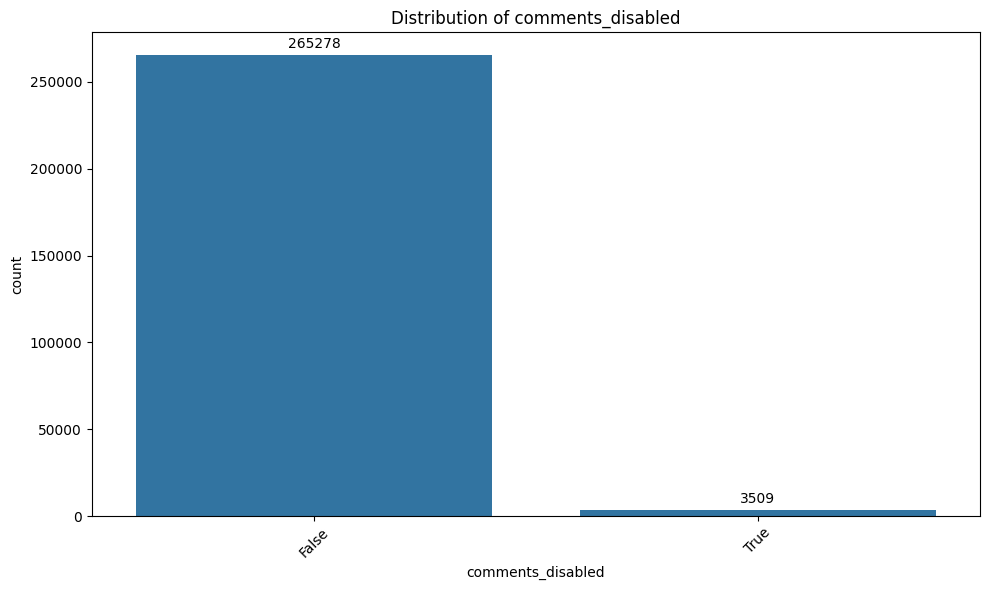

In [24]:
plot_categorical_distribution(df, 'comments_disabled')

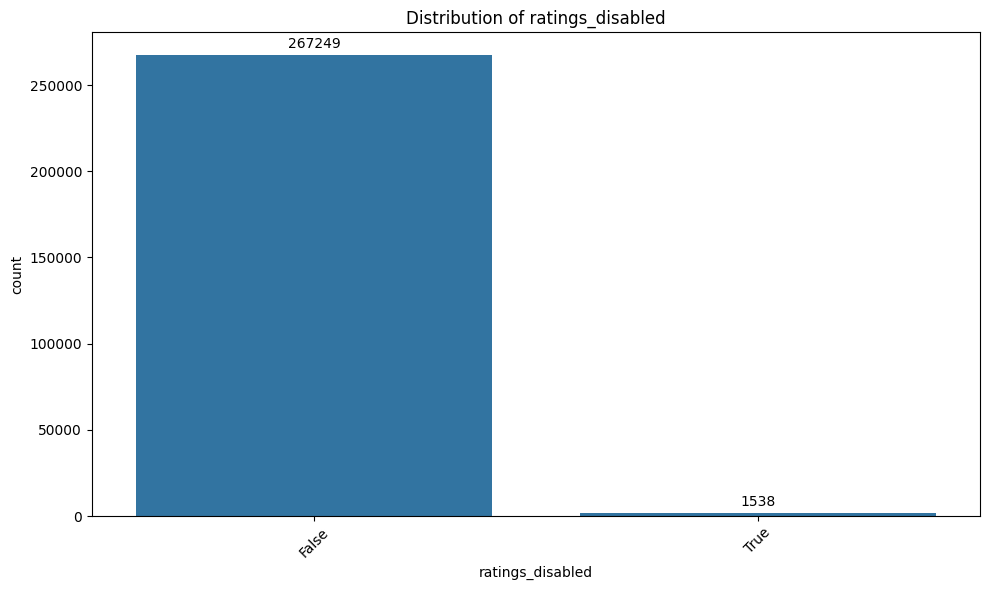

In [25]:
plot_categorical_distribution(df, 'ratings_disabled')

##### in both ```ratings_disabled``` and ```comments_disabled``` columns, ```True``` hold a very small percentage, we should consider to drop this 2 columns because there are no statistical impact provided

### Misssing values

In [26]:
def missing_val_percent(X):
    """
    Hàm tính phần trăm giá trị bị thiếu (missing values) trong mỗi cột của DataFrame.

    Args:
        X (pd.DataFrame): DataFrame cần kiểm tra giá trị bị thiếu.

    Returns:
        None: In ra tên các cột có giá trị bị thiếu và phần trăm giá trị bị thiếu trong từng cột.
    """

    range = len(X)
    for col in X.columns:
        if X[col].isnull().sum() != 0:
            print(f'{col} : {(X[col].isnull().sum() / range) * 100}%')

missing_val_percent(df)

description : 1.6924181601044692%


#### Conclusion:

- `ratings_disabled` and `comments_disabled` will be removed due to insignificant statistical value, including `thumbnal_links` with no real insight


# Pre-processing

## Codebook

- **video_id**: id of video 
- **title**: title of the video
- **publishedAt**: date of published video  
- **channelId**: Id of the channel 
- **channelTitle**: title of the channel 
- **categoryId**: Id of the category  
- **trending_date**: trending date of the video (maybe drop)
- **tags**: tags of the video  
- **view_count**: view count of the video
- **likes**: number of likes  
- **dislikes**: number of dislikes  
- **comment_count**: number of comments  
- **thumbnail_link**: url of the thumbnail image (drop)
- **comments_disabled**: boolen : comments disabled or not
- **ratings_disabled**: rating disabled or not
- **description**: description of the video